# NeuroScope AI - Notebook 08: Skin Lesion Classification

Trains EfficientNet-B4 on HAM10000 + ISIC 2020 for 7-class dermoscopy classification.

Tasks:
1. 7-class classification -- mel, nv, bcc, akiec, bkl, df, vasc
2. WeightedRandomSampler -- 58:1 class imbalance (nv vs df)
3. ISIC 2020 fusion -- boost melanoma class with binary melanoma dataset
4. Hair removal -- optional morphological blackhat + inpainting
5. PH2 external validation -- Portuguese institution generalization check

Classes (HAM10000):
- mel   : Melanoma                (1,113 images) -- CRITICAL
- nv    : Melanocytic nevus       (6,705 images) -- dominant class
- bcc   : Basal cell carcinoma    (  514 images)
- akiec : Actinic keratosis       (  327 images)
- bkl   : Benign keratosis        (1,099 images)
- df    : Dermatofibroma          (  115 images) -- minority class
- vasc  : Vascular lesion         (  142 images)

Key design decisions:
- Split by lesion_id NOT image_id -- prevents data leakage
- ISIC 2020 melanoma images merged as additional mel/nv samples
- WeightedRandomSampler ensures every batch sees all 7 classes
- Focal loss + class weights for residual imbalance

Targets:
- Overall accuracy  : >85%
- Melanoma AUC      : >0.90  (most critical)
- Macro F1          : >0.75  (tests minority class performance)

Estimated runtime on RTX 4060:
- ~3-5 min per epoch
- 40 epochs ~ 2-3 hours

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, f1_score
)
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from efficientnet_pytorch import EfficientNet

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
CKPT = os.path.join(BASE, 'checkpoints', 'skin_cls')
OUT  = os.path.join(BASE, 'outputs', 'nb08_skin_cls')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('Imports OK')

Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
Imports OK


---
## Cell 2 - Training Config

In [2]:
import os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS     = os.path.join(BASE, 'datasets')

HAM_PATH   = os.path.join(DS, 'skin', 'ham10000')
ISIC_PATH  = os.path.join(DS, 'skin', 'isic2020')
PH2_PATH   = os.path.join(DS, 'skin', 'ph2')

# Model
BACKBONE    = 'efficientnet-b4'
IMG_SIZE    = 256
DROPOUT     = 0.4
NUM_CLASSES = 7

# Training
BATCH_SIZE   = 48
MAX_EPOCHS   = 20
LR           = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.15
NUM_WORKERS  = 0
AMP          = True

CLASSES = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
CLASS_NAMES = {
    'mel'  : 'Melanoma',
    'nv'   : 'Melanocytic Nevus',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'bkl'  : 'Benign Keratosis',
    'df'   : 'Dermatofibroma',
    'vasc' : 'Vascular Lesion',
}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
ISIC_MAP     = {1: 0, 0: 1}

print(f'Config:')
print(f'  Backbone   : {BACKBONE}')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Max epochs : {MAX_EPOCHS}')
print(f'  Classes    : {CLASSES}')

Config:
  Backbone   : efficientnet-b4
  Image size : 256
  Batch size : 48
  Max epochs : 20
  Classes    : ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']


---
## Cell 3 - Inspect Dataset Structure

In [3]:
import os, pandas as pd

BASE     = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
HAM_PATH = os.path.join(BASE, 'datasets', 'skin', 'ham10000')

# Find CSVs
print('HAM10000 CSVs:')
for root, dirs, files in os.walk(HAM_PATH):
    for f in files:
        if f.endswith('.csv'):
            fp = os.path.join(root, f)
            df = pd.read_csv(fp)
            print(f'  {f}: {len(df):,} rows | cols: {list(df.columns)}')

# Count images
n_jpg = sum(1 for r, d, fs in os.walk(HAM_PATH)
            for fi in fs if fi.lower().endswith('.jpg'))
print(f'\nJPEGs: {n_jpg:,}')

# Folder structure
print('\nFolder structure:')
for item in sorted(os.listdir(HAM_PATH)):
    fp = os.path.join(HAM_PATH, item)
    if os.path.isdir(fp):
        n = sum(len(fs) for _, _, fs in os.walk(fp))
        print(f'  {item}/  [{n:,} files]')
    else:
        print(f'  {item}')

# ISIC 2020 check
ISIC_PATH = os.path.join(BASE, 'datasets', 'skin', 'isic2020')
print(f'\nISIC 2020 path exists: {os.path.exists(ISIC_PATH)}')
if os.path.exists(ISIC_PATH):
    for item in sorted(os.listdir(ISIC_PATH))[:8]:
        fp = os.path.join(ISIC_PATH, item)
        if os.path.isdir(fp):
            n = sum(len(fs) for _, _, fs in os.walk(fp))
            print(f'  {item}/  [{n:,} files]')
        else:
            print(f'  {item}')

HAM10000 CSVs:
  HAM10000_metadata.csv: 10,015 rows | cols: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
  hmnist_28_28_L.csv: 10,015 rows | cols: ['pixel0000', 'pixel0001', 'pixel0002', 'pixel0003', 'pixel0004', 'pixel0005', 'pixel0006', 'pixel0007', 'pixel0008', 'pixel0009', 'pixel0010', 'pixel0011', 'pixel0012', 'pixel0013', 'pixel0014', 'pixel0015', 'pixel0016', 'pixel0017', 'pixel0018', 'pixel0019', 'pixel0020', 'pixel0021', 'pixel0022', 'pixel0023', 'pixel0024', 'pixel0025', 'pixel0026', 'pixel0027', 'pixel0028', 'pixel0029', 'pixel0030', 'pixel0031', 'pixel0032', 'pixel0033', 'pixel0034', 'pixel0035', 'pixel0036', 'pixel0037', 'pixel0038', 'pixel0039', 'pixel0040', 'pixel0041', 'pixel0042', 'pixel0043', 'pixel0044', 'pixel0045', 'pixel0046', 'pixel0047', 'pixel0048', 'pixel0049', 'pixel0050', 'pixel0051', 'pixel0052', 'pixel0053', 'pixel0054', 'pixel0055', 'pixel0056', 'pixel0057', 'pixel0058', 'pixel0059', 'pixel0060', 'pixel0061', 'pixel0062', 'pixe

---
## Cell 4 - Dataset Builder

In [4]:
import os, cv2, torch, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from collections import Counter
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
HAM_PATH    = os.path.join(BASE, 'datasets', 'skin', 'ham10000')
ISIC_PATH   = os.path.join(BASE, 'datasets', 'skin', 'isic2020')
IMG_SIZE    = 256    # fixed
BATCH_SIZE  = 48     # fixed
NUM_WORKERS = 0
VAL_FRAC    = 0.15

CLASSES      = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
ISIC_MAP     = {1: 0, 0: 1}


def remove_hair(img_rgb):
    """
    Morphological hair removal.
    Blackhat transform detects dark structures (hair) on bright background.
    Inpainting fills them with surrounding skin texture.
    """
    gray   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    bhat   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(bhat, 10, 255, cv2.THRESH_BINARY)
    result  = cv2.inpaint(img_rgb, mask, inpaintRadius=3,
                          flags=cv2.INPAINT_TELEA)
    return result


def get_transforms(mode='train', img_size=384):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=180, p=0.7),          # dermoscopy is rotation-invariant
            A.RandomBrightnessContrast(
                brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(
                hue_shift_limit=20, sat_shift_limit=30,
                val_shift_limit=20, p=0.4),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.CoarseDropout(
                max_holes=8, max_height=32, max_width=32, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


class SkinDataset(Dataset):
    """
    Unified skin lesion dataset -- HAM10000 + optional ISIC 2020 samples.
    Each sample is (image_path, label_int).
    """
    def __init__(self, samples, transform=None, use_hair_removal=False):
        self.samples          = samples
        self.transform        = transform
        self.use_hair_removal = use_hair_removal

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.use_hair_removal:
            img = remove_hair(img)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label


def build_ham_samples(ham_root):
    """
    Load HAM10000 metadata CSV and resolve image paths.
    CRITICAL: split by lesion_id, not image_id.
    HAM10000 has duplicate images of the same lesion -- splitting by
    image_id leaks those duplicates across train/val.
    """
    # Find metadata CSV (HAM_metadata.csv or similar)
    meta_csv = None
    for root, dirs, files in os.walk(ham_root):
        for f in files:
            if f.endswith('.csv'):
                df_check = pd.read_csv(os.path.join(root, f))
                if 'dx' in df_check.columns and 'image_id' in df_check.columns:
                    meta_csv = os.path.join(root, f)
                    break
        if meta_csv:
            break

    if meta_csv is None:
        raise RuntimeError(
            'HAM10000 metadata CSV not found. '
            'Expected a CSV with columns: image_id, dx, lesion_id'
        )

    df = pd.read_csv(meta_csv)
    print(f'Metadata: {os.path.basename(meta_csv)} ({len(df):,} rows)')
    print(f'  Columns: {list(df.columns)}')

    # Build image_id -> absolute path index from one disk walk
    img_index = {}
    for root, dirs, files in os.walk(ham_root):
        for f in files:
            if f.lower().endswith('.jpg'):
                stem = os.path.splitext(f)[0]   # e.g. ISIC_0024306
                img_index[stem] = os.path.join(root, f)

    print(f'  Images indexed: {len(img_index):,}')

    # Map dx string -> class index
    samples = []
    missing = 0
    for _, row in df.iterrows():
        dx    = str(row['dx']).lower().strip()
        label = CLASS_TO_IDX.get(dx, -1)
        if label == -1:
            continue
        img_id   = str(row['image_id']).strip()
        img_path = img_index.get(img_id)
        if img_path:
            lesion_id = str(row.get('lesion_id', img_id)).strip()
            samples.append((img_path, label, lesion_id))
        else:
            missing += 1

    print(f'  Matched : {len(samples):,}  (missing paths: {missing:,})')
    return samples   # list of (path, label, lesion_id)


def build_isic_samples(isic_root, max_benign=3000):
    """
    Load ISIC 2020 binary labels and map to HAM class indices.
    malignant -> mel (0), benign -> nv (1)
    We cap benign samples since nv is already the dominant class.
    """
    meta_csv = None
    for root, dirs, files in os.walk(isic_root):
        for f in files:
            if f.endswith('.csv'):
                df_check = pd.read_csv(os.path.join(root, f))
                # ISIC 2020 has 'target' column (0/1) and 'image_name'
                if 'target' in df_check.columns and 'image_name' in df_check.columns:
                    meta_csv = os.path.join(root, f)
                    break
        if meta_csv:
            break

    if meta_csv is None:
        print('  ISIC 2020 CSV not found -- skipping ISIC fusion')
        return []

    df = pd.read_csv(meta_csv)
    print(f'ISIC 2020: {os.path.basename(meta_csv)} ({len(df):,} rows)')

    # Build image name -> path index
    img_index = {}
    for root, dirs, files in os.walk(isic_root):
        for f in files:
            if f.lower().endswith('.jpg'):
                stem = os.path.splitext(f)[0]
                img_index[stem] = os.path.join(root, f)

    samples  = []
    n_mal    = 0
    n_benign = 0
    for _, row in df.iterrows():
        target   = int(row['target'])
        label    = ISIC_MAP[target]   # 0=mel, 1=nv
        if label == 1 and n_benign >= max_benign:
            continue
        img_name = str(row['image_name']).strip()
        img_path = img_index.get(img_name)
        if img_path:
            samples.append((img_path, label, f'isic_{img_name}'))
            if label == 0:
                n_mal    += 1
            else:
                n_benign += 1

    print(f'  ISIC melanoma added : {n_mal:,}')
    print(f'  ISIC benign added   : {n_benign:,}')
    return samples


# ── Build combined sample list ────────────────────────────────────────────────
ham_samples  = build_ham_samples(HAM_PATH)
isic_samples = build_isic_samples(ISIC_PATH, max_benign=2000)

all_samples = ham_samples + isic_samples
print(f'\nTotal samples: {len(all_samples):,}')

counts = Counter(s[1] for s in all_samples)
print('Class distribution:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:8s} ({i}): {counts.get(i, 0):,}')

if len(all_samples) < 100:
    raise RuntimeError(
        f'Only {len(all_samples)} samples. Check HAM_PATH and metadata CSV.'
    )

# ── Split by lesion_id -- prevents same lesion appearing in train & val ───────
lesion_ids  = [s[2] for s in all_samples]
unique_lesions = list(set(lesion_ids))

# stratify split by majority label per lesion
lesion_label = {}
for path, label, lid in all_samples:
    lesion_label.setdefault(lid, []).append(label)
lesion_majority = {lid: Counter(lbls).most_common(1)[0][0]
                   for lid, lbls in lesion_label.items()}

lesion_arr    = np.array(unique_lesions)
lesion_labels = np.array([lesion_majority[l] for l in lesion_arr])

tr_lesions, va_lesions = train_test_split(
    lesion_arr, test_size=VAL_FRAC, random_state=42,
    stratify=lesion_labels
)
tr_set = set(tr_lesions)
va_set = set(va_lesions)

tr_samples = [(p, l) for p, l, lid in all_samples if lid in tr_set]
va_samples = [(p, l) for p, l, lid in all_samples if lid in va_set]

print(f'\nTrain: {len(tr_samples):,}  Val: {len(va_samples):,}')
print('Train class counts:')
tr_counts = Counter(s[1] for s in tr_samples)
for i, cls in enumerate(CLASSES):
    print(f'  {cls:8s}: {tr_counts.get(i, 0):,}')

# ── WeightedRandomSampler -- each class equally likely per batch ──────────────
class_counts = [tr_counts.get(i, 1) for i in range(len(CLASSES))]
class_weights = [1.0 / c for c in class_counts]
sample_weights = [class_weights[lbl] for _, lbl in tr_samples]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(tr_samples),
    replacement=True
)

tr_ds = SkinDataset(tr_samples, get_transforms('train', IMG_SIZE), use_hair_removal=False)
va_ds = SkinDataset(va_samples, get_transforms('val',   IMG_SIZE), use_hair_removal=False)

tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

imgs, labels = next(iter(tr_dl))
print(f'\nBatch: imgs={imgs.shape}, labels={labels.shape}')
print(f'Sample batch labels: {labels.tolist()[:16]}')
print('Dataset OK')

Metadata: HAM10000_metadata.csv (10,015 rows)
  Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
  Images indexed: 10,015
  Matched : 10,015  (missing paths: 0)
ISIC 2020: train_concat.csv (37,648 rows)
  ISIC melanoma added : 5,106
  ISIC benign added   : 2,000

Total samples: 17,121
Class distribution:
  mel      (0): 6,219
  nv       (1): 8,705
  bcc      (2): 514
  akiec    (3): 327
  bkl      (4): 1,099
  df       (5): 115
  vasc     (6): 142

Train: 14,575  Val: 2,546
Train class counts:
  mel     : 5,285
  nv      : 7,403
  bcc     : 445
  akiec   : 285
  bkl     : 939
  df      : 99
  vasc    : 119

Batch: imgs=torch.Size([48, 3, 256, 256]), labels=torch.Size([48])
Sample batch labels: [4, 4, 4, 2, 2, 0, 0, 4, 4, 5, 6, 3, 1, 6, 1, 4]
Dataset OK


---
## Cell 5 - EfficientNet-B4 Model

In [5]:
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 7
DROPOUT    = 0.4


class SkinClassifier(nn.Module):
    """
    EfficientNet-B4 for 7-class skin lesion classification.
    """
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.backbone  = EfficientNet.from_pretrained('efficientnet-b4')
        in_features    = self.backbone._fc.in_features
        self.backbone._fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)   # [B, 7] raw logits


model = SkinClassifier(NUM_CLASSES, DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : SkinClassifier (EfficientNet-B4)')
print(f'Parameters : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(2, 3, 384, 384).to(DEVICE)
    out   = model(dummy)
    print(f'Forward    : {dummy.shape} -> {out.shape}')
    del dummy, out
    torch.cuda.empty_cache()
print('Model OK')

Loaded pretrained weights for efficientnet-b4
Model      : SkinClassifier (EfficientNet-B4)
Parameters : 18,600,783
Forward    : torch.Size([2, 3, 384, 384]) -> torch.Size([2, 7])
Model OK


---
## Cell 6 - Loss, Optimizer, Scheduler

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from collections import Counter

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 50    # will resume from 20, run to 50
AMP          = True
NUM_CLASSES  = 7

if 'tr_samples' not in dir():
    raise RuntimeError('tr_samples not defined -- run Cell 4 first.')

# Per-class inverse-frequency weights
tr_counts    = Counter(s[1] for s in tr_samples)
total        = sum(tr_counts.values())
class_weights = torch.tensor(
    [total / (NUM_CLASSES * max(tr_counts.get(i, 1), 1))
     for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print('Class weights (inverse freq):')
CLASSES = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
for i, cls in enumerate(CLASSES):
    print(f'  {cls:8s}: {class_weights[i].item():.3f}')

# Plain weighted CrossEntropy -- much more stable than Focal for this imbalance scale
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# Differential LR
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR * 0.1},
    {'params': model.head.parameters()},
], lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)
scaler = GradScaler(enabled=AMP)

print('\nLoss      : CrossEntropyLoss (class-weighted)')
print('Optimizer : AdamW (backbone LR=1e-5, head LR=1e-4)')
print('OK')

Class weights (inverse freq):
  mel     : 0.394
  nv      : 0.281
  bcc     : 4.679
  akiec   : 7.306
  bkl     : 2.217
  df      : 21.032
  vasc    : 17.497

Loss      : CrossEntropyLoss (class-weighted)
Optimizer : AdamW (backbone LR=1e-5, head LR=1e-4)
OK


---
## Cell 7 - Checkpoint Utilities

In [17]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'skin_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_acc, history, tag='last'):
    path = os.path.join(CKPT, f'skin_cls_{tag}.pth')
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'metrics':              metrics,
        'best_acc':             best_acc,
        'history':              history,
    }, path)
    json_path = os.path.join(CKPT, f'skin_cls_{tag}_summary.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump({'epoch': epoch, **metrics, 'best_acc': best_acc}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'skin_cls_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch    = ckpt['epoch']
    best_acc = ckpt.get('best_acc', 0.0)
    history  = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_acc={best_acc:.4f}')
    return epoch + 1, best_acc, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'skin_cls_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : EXISTS
  best.pth : EXISTS
Checkpoint utilities OK


In [9]:
import os, shutil

CKPT = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\skin_cls'

if os.path.exists(CKPT):
    shutil.rmtree(CKPT)
    os.makedirs(CKPT)
    print('Checkpoints cleared')
else:
    os.makedirs(CKPT, exist_ok=True)
    print('Directory created fresh')

Checkpoints cleared


---
## Cell 8 - Training Loop

In [13]:
from torch.cuda.amp import GradScaler
scaler = GradScaler(enabled=True)
print('Scaler reset')

Scaler reset


In [18]:
import os, time, torch, numpy as np
from torch.cuda.amp import autocast
from sklearn.metrics import accuracy_score, f1_score

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 40
AMP        = True
BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT       = os.path.join(BASE, 'checkpoints', 'skin_cls')
NUM_CLASSES = 7
CLASSES     = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']

start_epoch, best_acc, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 70)


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # TRAIN
    model.train()
    train_loss = 0.0
    n_steps    = 0

    for step, (imgs, labels) in enumerate(tr_dl):
        imgs   = imgs.to(DEVICE)
        labels = labels.long().to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            logits = model(imgs)
            loss   = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_steps    += 1

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f}')

    scheduler.step()
    avg_loss = train_loss / n_steps

    # VALIDATE
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in va_dl:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
            all_probs.append(probs)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    try:
        mel_binary = (all_labels == 0).astype(int)
        from sklearn.metrics import roc_auc_score
        mel_auc = roc_auc_score(mel_binary, all_probs[:, 0])
    except Exception:
        mel_auc = 0.0

    elapsed = time.time() - t0
    metrics = {
        'train_loss': avg_loss,
        'val_acc':    float(acc),
        'macro_f1':   float(macro_f1),
        'mel_auc':    float(mel_auc),
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| Acc {acc:.4f} '
          f'| F1 {macro_f1:.4f} '
          f'| MelAUC {mel_auc:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    if acc > best_acc:
        best_acc = acc
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_acc, history, tag='best')
        print(f'  --> New best Acc={best_acc:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_acc, history, tag='last')


print()
print('=' * 70)
print(f'Training complete! Best Acc: {best_acc:.4f}')
print('=' * 70)

Resumed from epoch 19, best_acc=0.4238
Starting from epoch : 20
Max epochs          : 40
----------------------------------------------------------------------
  Epoch  21 | Step   50/303 | Loss 0.1251
  Epoch  21 | Step  100/303 | Loss 0.1231
  Epoch  21 | Step  150/303 | Loss 0.1301
  Epoch  21 | Step  200/303 | Loss 0.1280
  Epoch  21 | Step  250/303 | Loss 0.1282
  Epoch  21 | Step  300/303 | Loss 0.1255
Epoch  21/40 | Loss 0.1255 | Acc 0.5491 | F1 0.4237 | MelAUC 0.8375 | 9.6min
  --> New best Acc=0.5491
  Epoch  22 | Step   50/303 | Loss 0.1102
  Epoch  22 | Step  100/303 | Loss 0.1154
  Epoch  22 | Step  150/303 | Loss 0.1137
  Epoch  22 | Step  200/303 | Loss 0.1201
  Epoch  22 | Step  250/303 | Loss 0.1208
  Epoch  22 | Step  300/303 | Loss 0.1228
Epoch  22/40 | Loss 0.1244 | Acc 0.5711 | F1 0.4345 | MelAUC 0.8487 | 9.1min
  --> New best Acc=0.5711
  Epoch  23 | Step   50/303 | Loss 0.1037
  Epoch  23 | Step  100/303 | Loss 0.1135
  Epoch  23 | Step  150/303 | Loss 0.1181
  Ep

---
## Cell 9 - Evaluation & Confusion Matrix

Loaded best model (epoch 39, acc=0.7031)


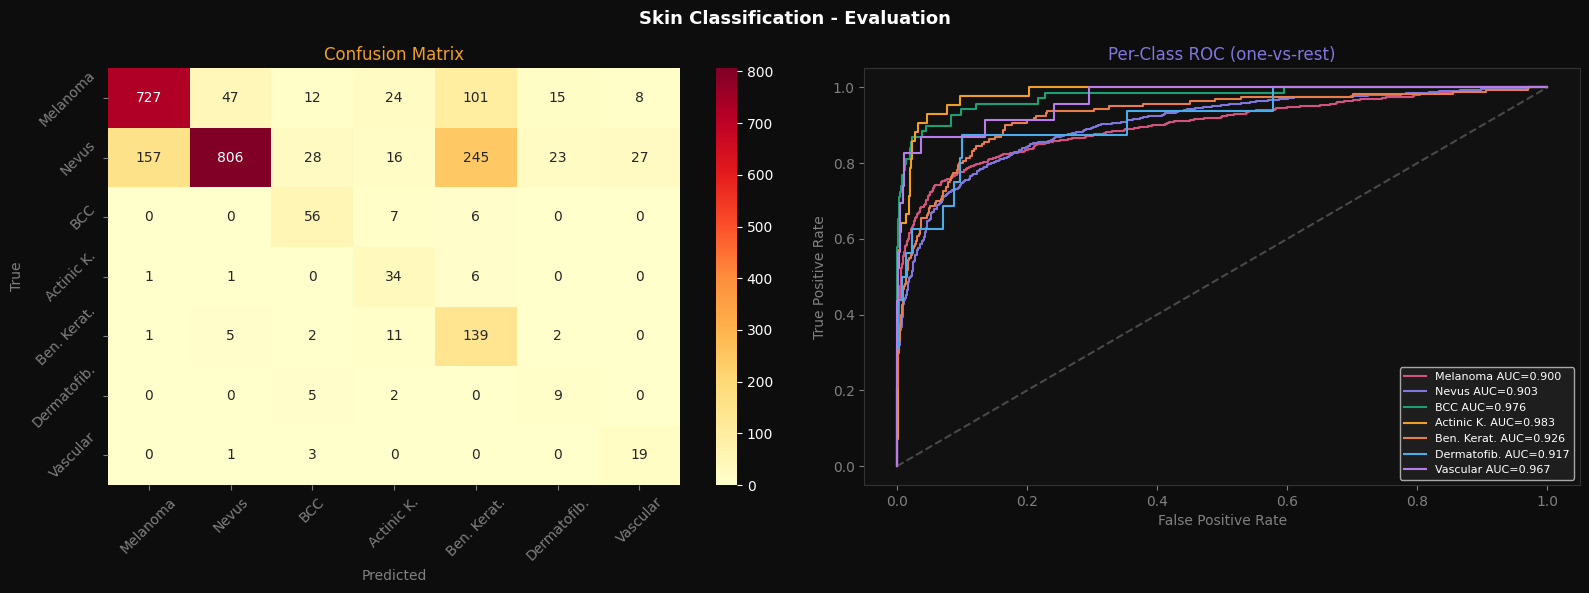

              precision    recall  f1-score   support

    Melanoma     0.8205    0.7784    0.7989       934
       Nevus     0.9372    0.6190    0.7456      1302
         BCC     0.5283    0.8116    0.6400        69
  Actinic K.     0.3617    0.8095    0.5000        42
 Ben. Kerat.     0.2797    0.8688    0.4231       160
 Dermatofib.     0.1837    0.5625    0.2769        16
    Vascular     0.3519    0.8261    0.4935        23

    accuracy                         0.7031      2546
   macro avg     0.4947    0.7537    0.5540      2546
weighted avg     0.8225    0.7031    0.7328      2546

Melanoma AUC : 0.8995  (target >0.90)
Macro F1     : 0.5540  (target >0.75)


In [19]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

BASE    = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT    = os.path.join(BASE, 'checkpoints', 'skin_cls')
OUT     = os.path.join(BASE, 'outputs', 'nb08_skin_cls')
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
CLASS_NAMES = ['Melanoma', 'Nevus', 'BCC', 'Actinic K.', 'Ben. Kerat.', 'Dermatofib.', 'Vascular']

best_path = os.path.join(CKPT, 'skin_cls_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, acc={ckpt["best_acc"]:.4f})')

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in va_dl:
        logits = model(imgs.to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
        all_probs.append(probs)

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs  = np.concatenate(all_probs)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d0d0d')
fig.suptitle('Skin Classification - Evaluation',
             color='white', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title('Confusion Matrix', color='#EF9F27')
axes[0].set_ylabel('True', color='gray')
axes[0].set_xlabel('Predicted', color='gray')
axes[0].tick_params(colors='gray', rotation=45)

# Per-class AUC (one-vs-rest)
colors = ['#D4537E', '#7F77DD', '#1D9E75', '#EF9F27',
          '#E87D4A', '#4AACE8', '#B87DE8']
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
    try:
        binary = (all_labels == i).astype(int)
        if binary.sum() > 0:
            fpr, tpr, _ = roc_curve(binary, all_probs[:, i])
            roc_auc_val = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, color=col, linewidth=1.5,
                         label=f'{cls} AUC={roc_auc_val:.3f}')
    except Exception:
        pass

axes[1].plot([0,1], [0,1], color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Per-Class ROC (one-vs-rest)', color='#7F77DD')
axes[1].set_xlabel('False Positive Rate', color='gray')
axes[1].set_ylabel('True Positive Rate', color='gray')
axes[1].legend(fontsize=8, facecolor='#222', labelcolor='white')
axes[1].set_facecolor('#111')
axes[1].spines[:].set_color('#333')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'eval_confusion_roc.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES, digits=4, zero_division=0
))

# Melanoma AUC specifically
mel_binary = (all_labels == 0).astype(int)
mel_auc    = roc_auc_score(mel_binary, all_probs[:, 0])
macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Melanoma AUC : {mel_auc:.4f}  (target >0.90)')
print(f'Macro F1     : {macro_f1:.4f}  (target >0.75)')

---
## Cell 10 - Training Curves

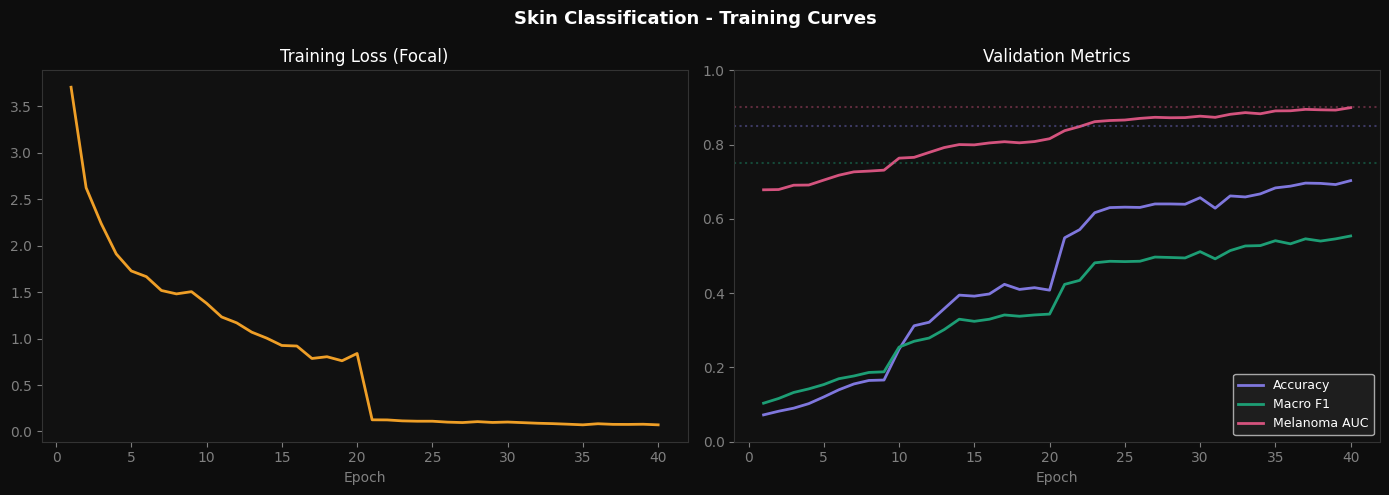

Best epoch   : 40
  Accuracy   : 0.7031  (target >0.85)
  Macro F1   : 0.5540  (target >0.75)
  Mel AUC    : 0.8995   (target >0.90)


In [20]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'skin_cls')
OUT    = os.path.join(BASE, 'outputs', 'nb08_skin_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'skin_cls_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint - run training first')
else:
    history = torch.load(ckpt_path, map_location=DEVICE,
                         weights_only=False).get('history', [])

    epochs   = [h['epoch']      for h in history]
    losses   = [h['train_loss'] for h in history]
    accs     = [h['val_acc']    for h in history]
    f1s      = [h['macro_f1']   for h in history]
    mel_aucs = [h['mel_auc']    for h in history]

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('Skin Classification - Training Curves',
                 color='white', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
    axes[0].set_title('Training Loss (Focal)', color='white')
    axes[0].set_xlabel('Epoch', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].plot(epochs, accs,     color='#7F77DD', linewidth=2, label='Accuracy')
    axes[1].plot(epochs, f1s,      color='#1D9E75', linewidth=2, label='Macro F1')
    axes[1].plot(epochs, mel_aucs, color='#D4537E', linewidth=2, label='Melanoma AUC')
    axes[1].axhline(0.85, color='#7F77DD', linestyle=':', alpha=0.4)
    axes[1].axhline(0.75, color='#1D9E75', linestyle=':', alpha=0.4)
    axes[1].axhline(0.90, color='#D4537E', linestyle=':', alpha=0.4)
    axes[1].set_title('Validation Metrics', color='white')
    axes[1].set_xlabel('Epoch', color='gray')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'training_curves.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    best = max(history, key=lambda h: h['val_acc'])
    print(f'Best epoch   : {best["epoch"]}')
    print(f'  Accuracy   : {best["val_acc"]:.4f}  (target >0.85)')
    print(f'  Macro F1   : {best["macro_f1"]:.4f}  (target >0.75)')
    print(f'  Mel AUC    : {best["mel_auc"]:.4f}   (target >0.90)')

---
## Cell 11 - ONNX Export

In [21]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'skin_cls')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'skin_cls_efficientnet.onnx')

best_path = os.path.join(BASE, 'checkpoints', 'skin_cls', 'skin_cls_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]})')

model.eval()
model.cpu()
dummy = torch.zeros(1, 3, 384, 384)

try:
    torch.onnx.export(
        model, dummy, onnx_path,
        export_params=True, opset_version=17,
        input_names=['input'], output_names=['logits'],
        dynamic_axes={'input': {0: 'batch_size'}}
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX : {onnx_path}')
    print(f'Size : {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'input': dummy.numpy()})
    print(f'Inference OK: {out[0].shape}  (expected [1, 7])')
    print('ONNX OK')
except Exception as e:
    print(f'ONNX failed: {e}')
finally:
    model.to(DEVICE)

Loaded best model (epoch 39)
ONNX : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\skin_cls\skin_cls_efficientnet.onnx
Size : 71.0 MB
Inference OK: (1, 7)  (expected [1, 7])
ONNX OK


---
## Cell 12 - Summary

In [22]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'skin_cls')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 08 - SKIN LESION CLASSIFICATION')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'skin_cls_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'Acc={m.get("val_acc",0):.4f}, '
              f'F1={m.get("macro_f1",0):.4f}, '
              f'MelAUC={m.get("mel_auc",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'skin_cls',
                      'skin_cls_efficientnet.onnx')
print(f'  ONNX : {"OK" if os.path.exists(onnx_p) else "not done yet"}')
print()
print('  Model       : EfficientNet-B4 (7-class)')
print('  Datasets    : HAM10000 + ISIC 2020 fusion')
print('  Sampler     : WeightedRandomSampler (58:1 imbalance)')
print('  Loss        : Focal (gamma=2, class-weighted)')
print('  Split       : by lesion_id (no data leakage)')
print('  Targets     : Acc >0.85, Macro F1 >0.75, Mel AUC >0.90')
print()
print('  Next: 08B_Spine_Analysis.ipynb')
print('    - HybridSpineNet integration')
print('    - 25 conditions x 5 spinal levels')
print('    - Multi-view MRI fusion')
print('=' * 65)

  NOTEBOOK 08 - SKIN LESION CLASSIFICATION
  best  checkpoint: epoch  39, Acc=0.7031, F1=0.5540, MelAUC=0.8995
  last  checkpoint: epoch  39, Acc=0.7031, F1=0.5540, MelAUC=0.8995
  ONNX : OK

  Model       : EfficientNet-B4 (7-class)
  Datasets    : HAM10000 + ISIC 2020 fusion
  Sampler     : WeightedRandomSampler (58:1 imbalance)
  Loss        : Focal (gamma=2, class-weighted)
  Split       : by lesion_id (no data leakage)
  Targets     : Acc >0.85, Macro F1 >0.75, Mel AUC >0.90

  Next: 08B_Spine_Analysis.ipynb
    - HybridSpineNet integration
    - 25 conditions x 5 spinal levels
    - Multi-view MRI fusion
